# Practicum: Conditional Memory Recall with Masked Stochastic Attention

In **L15a** and **L15b** you built a **Spiking Hebbian Memory Network (H-Mem)** in which one-shot associations are stored in a synaptic matrix `W_assoc` by Hebbian plasticity, and a key spike train is recalled by the matrix–vector product $\mathbf{v} = \mathbf{W}^{\mathrm{assoc}}\mathbf{k}$. Earlier in the term you saw a sister model: the **modern Hopfield network** of [Ramsauer et al. (2020)](https://arxiv.org/abs/2008.02217), in which stored memories sit on the columns of a matrix `X` and recall is one closed-form softmax-attention update $\mathbf{s} \leftarrow \mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s})$. **These are the same memory mechanism viewed two ways**: Hebbian when the inverse temperature $\beta \to \infty$, modern-Hopfield at finite $\beta$.

Recent work has pushed this idea one step further. If the modern-Hopfield retrieval rule is the *score function* of a Boltzmann distribution on the network's energy, then injecting Langevin noise into the update turns it into a *training-free generative sampler*. This is **Stochastic Attention (SA)**, used recently to generate small protein families ([Varner, 2026, arXiv:2603.14717](https://arxiv.org/abs/2603.14717)) and synthetic patient cohorts ([Varner et al., 2026, arXiv:2604.07557](https://arxiv.org/abs/2604.07557)) without any model training.

* __Hypothesis__: Suppose we store a balanced subset of MNIST digits as memory patterns and run Stochastic Attention from a random initial state. We should get back recognizable digits, drawn from a smoothed version of the dataset, not literally any image we stored. Now suppose we add a **mask** to the softmax (the same trick GPT uses for causal generation) that zeros out attention to every memory whose label is not the class we want. We should get *only* digits of the chosen class, with no model retraining and no change to the architecture.

This practicum asks you to verify both halves of that hypothesis: that SA over MNIST works as a training-free generator, and that a single boolean mask on the attention softmax is enough to make it class-conditional.

## Tasks
Before we get started, execute the `Run All Cells` command to check if you have any code or setup issues. For code issues, post a question on EdDiscussion.
* __Task 1: H-Mem ↔ modern Hopfield bridge__: recall a stored digit from the modern Hopfield network and sweep $\beta$ to see the soft-to-hard transition that connects the modern-Hopfield rule to the Hebbian rule from L15.
* __Task 2: Stochastic Attention sampling on MNIST__: run Langevin dynamics on the SA energy and visualize the generated digits. Tune the step size and the noise scale to balance fidelity against novelty.
* __Task 3: Masked SA = class-conditional generation__: add a single `Vector{Bool}` mask to the attention softmax to restrict generation to a chosen class. Compare the **hard mask** to the soft logit-bias trick of [Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115); use a nearest-mean classifier as a fidelity check.

Let's get started! (Don't forget to answer the discussion questions!)

___

## Learning Objectives
* __Bridge Hebbian recall and modern-Hopfield retrieval:__ Recognize that the H-Mem read step from L15 and the closed-form softmax-attention update of a modern Hopfield network describe the same associative-memory mechanism. Use the inverse temperature parameter to traverse the soft-to-hard transition between the two views.
* __Use Stochastic Attention as a training-free generator:__ Add Langevin-style noise to the modern-Hopfield update and treat the result as a sampler from the network's energy landscape. Tune the step size, the noise scale, and the inverse temperature to balance fidelity against novelty in the generated samples.
* __Steer generation by masking the attention softmax:__ Apply a boolean mask or a finite logit bias to the attention weights to restrict generation to a chosen subset of stored memories. Compare the two conditioning strategies and identify the calibration gap between attention-space conditioning and decoded output.


## Background: From H-Mem to modern Hopfield to Stochastic Attention
The same associative-memory mechanism shows up in three guises across this course.

In **L15a/L15b** you saw the **spiking H-Mem** of Limbacher and Legenstein ([2020](https://proceedings.neurips.cc/paper/2020/file/f6876a9f998f6472cc26708e27444456-Paper.pdf), [2022/2023](https://arxiv.org/abs/2205.11276)). Memories are written into a synaptic matrix `W_assoc` by Hebbian plasticity (the spike-trace outer-product rule), and a key spike train is recalled as $\mathbf{v} = \mathbf{W}^{\mathrm{assoc}}\mathbf{k}$.

The **modern Hopfield network** of [Ramsauer et al. (2020)](https://arxiv.org/abs/2008.02217) replaces `W_assoc` with the explicit memory matrix `X` (one stored pattern per column) and replaces the matrix–vector recall by one closed-form softmax-attention update,
$$\mathbf{s} \;\leftarrow\; \mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s}).$$
In the limit $\beta \to \infty$ the softmax becomes a one-hot, and the update is exactly the Hebbian read step you used in L15.

**Stochastic Attention (SA)** of [Varner (2026)](https://arxiv.org/abs/2603.14717) treats the modern-Hopfield log-sum-exp energy as a Boltzmann distribution and samples from it by Langevin dynamics,
$$\mathbf{s}_{t+1} \;=\; (1-\eta)\,\mathbf{s}_{t} + \eta\cdot\mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s}_{t}) \;+\; \sigma\cdot\boldsymbol{\xi}_{t},\qquad \boldsymbol{\xi}_{t}\sim\mathcal{N}(0, \mathbf{I}).$$
With $\sigma = 0$ and $\eta = 1$ this *is* the modern-Hopfield update; with $\sigma > 0$ it draws novel samples from a smoothed family, training-free.

### Why a mask?
Stochastic Attention treats every stored memory equally. To restrict generation to a *subset* of memories (say, all the 7s in MNIST), we add a boolean mask to the softmax: set the logit of every excluded pattern to $-\infty$. This is exactly the masking idea from causal language modeling in transformers, applied to a Hopfield memory rather than a sequence. 

[Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115) showed that a softer version, a finite scalar bias on the logits of the in-subset patterns, also works, and characterized the **calibration gap** between what the sampler steers toward in attention space and what the decoded output actually looks like.

In this practicum you will implement, run, and explore both versions on the MNIST dataset. But, wait, that is not all! You will also verify the equivalence of the H-Mem read step and the modern-Hopfield update, and you will tune the SA hyperparameters to balance fidelity against novelty in the generated samples. Wow!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the [`Include.jl`](Include.jl) file, which sets paths, loads external packages, seeds the RNG, and pulls in the practicum source files from `src/`:
* [`src/Types.jl`](src/Types.jl) defines the [`MyModernHopfieldNetworkModel`](src/Types.jl) and [`MyStochasticAttentionModel`](src/Types.jl) structs.
* [`src/Factory.jl`](src/Factory.jl) provides the [`build(...)`](src/Factory.jl) factories that construct each model from a `NamedTuple` of data.
* [`src/Compute.jl`](src/Compute.jl) implements the three core algorithms: [`modern_hopfield_recall`](src/Compute.jl), [`stochastic_attention_sample`](src/Compute.jl) (with optional `hard_mask` and `soft_bias` keyword arguments), and the [`classify_by_nearest_mean`](src/Compute.jl) reference classifier.
* [`src/Files.jl`](src/Files.jl) ships [`load_mnist_subset`](src/Files.jl) and the [`image_grid`](src/Files.jl) plotting helper.


In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/Practicum-5820-S2026`


### Constants
We fix two scalars up front so every cell below reads from a single set of knobs:

* `images_per_class::Int`, how many MNIST images per class to load. The repo ships 30 per class (300 total). Larger pools give richer SA generations but slow down the Langevin loop; 30 per class is plenty for this practicum.
* `β::Float64`, inverse temperature for both the modern-Hopfield recall and the SA sampler. Higher $\beta$ makes the softmax sharper (one stored pattern dominates); lower $\beta$ smears attention across multiple patterns.


In [2]:
images_per_class, β = let

    # initialize -
    images_per_class = 30; # TODO: how many MNIST images per class to memorize (Int between 1 and 30)
    β = 8.0;               # TODO: inverse temperature for the softmax (Float64 > 0). Try 1.0, 8.0, 50.0.

    # return -
    images_per_class, β;
end

(30, 8.0)

### Data
The `data/mnist/<class>/*.jpg` directory tree ships with this repository; there is nothing to download. The helper [`load_mnist_subset(...)`](src/Files.jl) reads up to `images_per_class` images from each of the ten classes, flattens each `28 × 28` image into a length-`784` vector, and stacks them as columns of a single memory matrix `X`. The companion vector `y` records the class label of each column.

The code below stores the memory matrix `X::Matrix{Float64}` (shape `784 × N`) and the class-label vector `y::Vector{Int}` (length `N`) for use in subsequent cells.


In [3]:
X, y = load_mnist_subset(images_per_class);

__Check__: confirm we have a `784 × N` memory matrix with one label per column and all ten digits present.

In [4]:
let
    @assert size(X, 1) == 784                                 # 28 × 28 pixels per image
    @assert size(X, 2) == 10 * images_per_class               # 10 classes × images_per_class
    @assert length(y) == size(X, 2)                           # one label per column
    @assert sort(unique(y)) == collect(0:9)                   # all ten digits present
end

__Preview__: peek at one image of each class to confirm we loaded MNIST and not, say, transposed garbage.

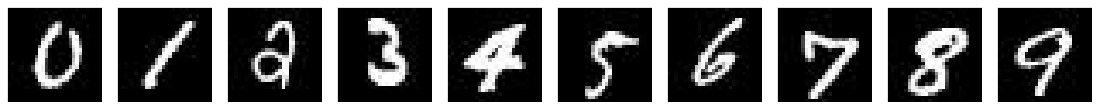

In [5]:
let
    one_per_class = hcat([X[:, findfirst(==(c), y)] for c in 0:9]...)
    image_grid(one_per_class, 10; title = "")
end

### Build the three models
We construct three Julia objects that the rest of the notebook will reuse:

* `mymodel::MyModernHopfieldNetworkModel`, the modern Hopfield network with the MNIST images on its columns and inverse temperature $\beta$. Used by Task 1.
* `sa_model::MyStochasticAttentionModel`, the Langevin sampler over the same memory matrix at the same $\beta$. Used by Task 2 and Task 3.
* `class_means::Dict{Int, Vector{Float64}}`, the per-class centroid of the stored patterns. Used by Task 3 as a deterministic, training-free reference classifier.

The factory functions live in [`src/Factory.jl`](src/Factory.jl); see [`src/Types.jl`](src/Types.jl) for the structs they populate.


In [6]:
mymodel, sa_model, class_means = let

    # initialize -
    mymodel = nothing;
    sa_model = nothing;
    class_means = nothing;

    # build the Hopfield and SA models -
    mymodel = build(MyModernHopfieldNetworkModel, (
        memories = X, # MNIST images on columns
        β        = β, # inverse temperature
    ));

    # build the SA model -
    sa_model = build(MyStochasticAttentionModel, (
        memories     = X,
        labels       = y,
        β            = β,    # reuse the same β for sampling
        step_size    = 1.0,  # TODO: try 0.25, 0.5, 1.0
        noise_scale  = 0.10, # TODO: try 0.02 (regurgitation), 0.10, 0.30
    ));

    # compute the class means for later evaluation -
    class_means = build_class_means(X, y);

    # return -
    mymodel, sa_model, class_means;
end

(MyModernHopfieldNetworkModel([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], 8.0), MyStochasticAttentionModel([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  9, 9, 9, 9, 9, 9, 9, 9, 9, 9], 8.0, 1.0, 0.1), Dict(0 => [0.00065359477124183, 0.000261437908496732, 0.0016993464052287581, 0.0016993464052287581, 0.0, 0.0, 0.001437908496732026, 0.0, 0.008888888888888887, 0.005882352941176471  …  0.000130718954248366, 0.00065359477124183, 0.000130718954248366, 0.000130718954248366, 0.00196078431372549, 0.000392156862745098, 0.0, 0.0, 0.0, 0.0], 4 => [0.000784313725490196, 0.000261437908496732, 0.000130718954248366, 0.00065359477124183, 0.0, 0.0, 0.001176470588235294, 0.0009150326797385621, 0.0030065359477124184, 0.00392156862745098  …  0.0, 0.00130718954248366, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 5 => [0.0, 0.0033986928104575162, 0.00065359477124183, 0.0, 0.000392156862745098, 0.00143790849

___

## Task 1: Are H-Mem and modern Hopfield the same thing?

**The claim.** The H-Mem read step from L15 is

$$\mathbf{v} \;=\; \mathbf{W}^{\mathrm{assoc}}\,\mathbf{k}, \qquad \mathbf{W}^{\mathrm{assoc}} \;=\; \sum_{j=1}^{N} \mathbf{v}_{j}\,\mathbf{k}_{j}^{\top}.$$

If the keys are *orthonormal* (or, more generally, if there is one key whose inner product with the cue dominates every other), this evaluates to $\mathbf{v}_{j^{\star}}$ where $j^{\star} = \arg\max_{j}\langle \mathbf{k}_{j}, \mathbf{k}\rangle$ — the value paired with the closest key. On the other hand, the modern-Hopfield update is given by:

$$\mathbf{p}_{\beta}(\mathbf{s}) \;=\; \mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s}),\qquad \mathbf{s}^{\prime} \;=\; \mathbf{X}\,\mathbf{p}_{\beta}(\mathbf{s}),$$

where the columns of $\mathbf{X}$ play the role of *both* keys and values (auto-association).

**The proof of equivalence in the high-$\beta$ limit comes in three steps:**

$$\textbf{Claim 1 (softmax → one-hot).}\qquad \lim_{\beta\to\infty} \mathbf{p}_{\beta}(\mathbf{s}) \;=\; \mathbf{e}_{j^{\star}},\qquad j^{\star} = \arg\max_{j}\langle \mathbf{X}_{:,j}, \mathbf{s}\rangle.$$

*Why:* the softmax of a linearly-scaled vector concentrates all mass on the unique maximizer as the scale grows, by the standard log-sum-exp argument.

$$\textbf{Claim 2 (same column wins).}\qquad \arg\max_{j} p_{\beta,j}(\mathbf{s}) \;=\; \arg\max_{j}\langle \mathbf{X}_{:,j}, \mathbf{s}\rangle \quad \text{for all } \beta > 0.$$

*Why:* the softmax is a strictly monotone function of its logits, so the index that maximizes the softmax weight is the same index that maximizes the underlying inner product, *at every* $\beta$. This is the bridge: the modern-Hopfield update agrees with H-Mem on **which** memory wins; $\beta$ only controls **how sharply** it commits.

$$\textbf{Claim 3 (output equals stored memory).}\qquad \mathbf{X}\,\mathbf{e}_{j^{\star}} \;=\; \mathbf{X}_{:,j^{\star}}.$$

*Why:* trivial — multiplying $\mathbf{X}$ by the standard basis vector $\mathbf{e}_{j^{\star}}$ selects the $j^{\star}$-th column. So in the high-$\beta$ limit, $\mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s}) \to \mathbf{X}_{:,j^{\star}}$ — and in the auto-associative case where keys = values = columns of $\mathbf{X}$, **this is exactly $\mathbf{v}_{j^{\star}}$, the H-Mem read step**. $\blacksquare$

**What you'll do in this task.** A proof on paper is not enough — we want to *see* each of the three claims hold on real MNIST data. The cells below run a recall at the default $\beta = 8$ and then check the three claims numerically:

* **Claim-1 witness**: $\max_{j}\,p_{\beta,j}(\hat{\mathbf{s}})$ at convergence — should be very close to $1$ (the softmax is one-hot up to numerical noise at $\beta = 8$).
* **Claim-2 witness**: compare $\arg\max_{j} p_{\beta,j}(\mathbf{s}_{\circ})$ with $\arg\max_{j}\langle \mathbf{X}_{:,j}, \mathbf{s}_{\circ}\rangle$ — they must be the *same column index* (no β needed; this holds for every β).
* **Claim-3 witness**: $\lVert \hat{\mathbf{s}}_{\circ} - \mathbf{X}_{:, j^{\star}}\rVert_{2}$ — should be $\approx 0$, confirming the converged state literally equals the dominant stored column.

Then, to drive home that the proof is about a *limit* (not a single $\beta$), the **β sweep** plots how peaked the attention distribution becomes as a function of $\beta$, using the scaled Shannon entropy $\tilde{H}(\beta) = H(\mathbf{p}_{\beta})/\log N \in [0, 1]$ from [Varner (2026, arXiv:2603.14717)](https://arxiv.org/abs/2603.14717). The curve runs from $\tilde{H} \approx 1$ (uniform — every memory contributes equally; pure soft averaging, far from H-Mem) to $\tilde{H} \approx 0$ (one-hot — Claim 1's limit; the H-Mem read step). The continuity of that descent is the *quantitative* version of "these are the same mechanism in different parameter regimes".

__Notation reminder__: $\mathbf{X} \in \mathbb{R}^{d \times N}$ is the memory matrix ($d = 784$ pixels, $N = 10\cdot\texttt{images\_per\_class}$ stored MNIST images, one per column); $\mathbf{s}, \mathbf{s}_{\circ}, \hat{\mathbf{s}}_{\circ} \in \mathbb{R}^{d}$ are state vectors in pixel space (current, seed, converged); $\mathbf{p}_{\beta}(\mathbf{s}) \in \Delta^{N-1}$ is the attention distribution over stored memories at inverse temperature $\beta > 0$.

The two cells below store the seed `sₒ::Vector{Float64}` and the integer index `memoryindextorecover::Int`, then call the recall routine which returns the converged state `ŝₒ::Vector{Float64}`, the per-iteration state dictionary `fₒ::Dict{Int,Vector{Float64}}`, and the per-iteration attention dictionary `pₒ::Dict{Int,Vector{Float64}}`.


In [7]:
memoryindextorecover, sₒ = let
    
    # initialize -
    memoryindextorecover = 100; # TODO: pick a column index in 1:size(X, 2)
    sₒ = mymodel.X[:, memoryindextorecover]; # the seed
    println("Seeding recall with column $(memoryindextorecover); true label = $(y[memoryindextorecover])")

    # return -
    memoryindextorecover, sₒ;
end

Seeding recall with column 100; true label = 3


(100, [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [8]:
ŝₒ, fₒ, pₒ = let

    # initialize -
    ŝₒ = nothing;
    fₒ = nothing;
    pₒ = nothing;

    # run the recall -
    (ŝₒ, fₒ, pₒ) = modern_hopfield_recall(mymodel, sₒ; maxiterations = 10_000, ϵ = 1e-12);
    println("Converged in $(length(fₒ)) iterations.")

    # return -
    ŝₒ, fₒ, pₒ;
end

Converged in 3 iterations.


([2.3471258588348597e-212, 3.9118764313914333e-213, 5.8582814531891654e-248, 2.6125891885497502e-297, 1.1735629294174299e-212, 7.322851816486457e-248, 1.0251992543081143e-247, 3.1295011451131467e-212, 2.677119733954333e-189, 3.53474832607404e-192  …  2.827798660859232e-192, 1.2090426500805998e-256, 1.413899330429616e-192, 7.240037894054373e-307, 2.2273410415689612e-269, 3.8882231586814436e-192, 0.0, 0.0, 0.0, 0.0], Dict(0 => [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 2 => [2.3471258588348597e-212, 3.9118764313914333e-213, 5.8582814531891654e-248, 2.6125891885497502e-297, 1.1735629294174299e-212, 7.322851816486457e-248, 1.0251992543081143e-247, 3.1295011451131467e-212, 2.677119733954333e-189, 3.53474832607404e-192  …  2.827798660859232e-192, 1.2090426500805998e-256, 1.413899330429616e-192, 7.240037894054373e-307, 2.2273410415689612e-269, 3.8882231586814436e-192, 0.0, 0.0, 0.0, 0.0], 1 => [9.736950404788496e-65, 1.622825067128

__Numerical proof — verifying the three claims at $\beta = 8$.__ The cell below pulls the converged attention vector $\mathbf{p}_{\beta}(\hat{\mathbf{s}}_{\circ})$ out of the recall and prints one number per claim. To pass the proof:
* Claim-1 witness should print $> 0.99$ (softmax is essentially one-hot).
* Claim-2 witness should print `agree? true` (softmax-argmax and inner-product-argmax pick the same column — this holds for *any* $\beta > 0$, not just $\beta = 8$).
* Claim-3 witness should print a number very close to $0$ (converged state equals the dominant stored column).


In [9]:
let
    # Claim 1 witness: softmax at the converged state is one-hot up to numerical noise.
    p_final = pₒ[length(fₒ) - 1]
    j_softmax = argmax(p_final)

    # Claim 2 witness: the argmax of the softmax (modern-Hopfield) and the argmax of the
    # raw inner-product (H-Mem read with auto-association) are the same column index.
    # We use the SEED sₒ here because Claim 2 is about which column the softmax picks at
    # any β > 0 — not about the converged fixed point — so it should hold even before
    # iterating to convergence.
    j_innerprod = argmax(transpose(X) * sₒ)

    # Claim 3 witness: the converged state equals the dominant stored column.
    claim3_residual = norm(ŝₒ .- X[:, j_softmax])

    println("Claim 1 — softmax → one-hot:           max(p) = $(round(maximum(p_final), digits = 6))")
    println("Claim 2 — same column wins (any β):    argmax softmax = $(j_softmax)   argmax ⟨X_j, sₒ⟩ = $(j_innerprod)   agree? $(j_softmax == j_innerprod)")
    println("Claim 3 — output = stored column:      ‖ŝ − X[:, j*]‖ = $(round(claim3_residual, digits = 6))")
    println()
    println("Dominant stored pattern: column $(j_softmax) (label $(y[j_softmax])) with attention weight $(round(maximum(p_final), digits = 4)).")
end

Claim 1 — softmax → one-hot:           max(p) = 1.0
Claim 2 — same column wins (any β):    argmax softmax = 108   argmax ⟨X_j, sₒ⟩ = 108   agree? true
Claim 3 — output = stored column:      ‖ŝ − X[:, j*]‖ = 0.0

Dominant stored pattern: column 108 (label 3) with attention weight 1.0.


__Visualize__: plot the seed, the recalled state, and the dominant stored memory side by side.

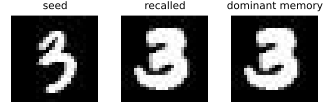

In [10]:
let
    p_final = pₒ[length(fₒ) - 1]
    j_dominant = argmax(p_final)
    grid = hcat(sₒ, ŝₒ, X[:, j_dominant])
    image_grid(grid, 3; tile_titles = ["seed", "recalled", "dominant memory"])
end

### The β sweep — visualizing the soft → hard transition
We just watched a *single* $\beta$ value (the default $\beta = 8$) drive the recall to a one-hot fixed point. To **see** that the sharpening is continuous in $\beta$ — and that the H-Mem read step is just the right-edge limit of the same family — we now sweep $\beta$ across four decades and measure how peaked the one-shot attention distribution $\mathbf{p}_{\beta} = \mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s}_{\circ})$ becomes. We measure peakedness with the **scaled Shannon entropy**

$$\tilde{H}(\beta) \;=\; \frac{H(\mathbf{p}_{\beta})}{\log N}, \qquad H(\mathbf{p}) \;=\; -\sum_{j=1}^{N} p_{j} \log p_{j}.$$

Dividing by $\log N$ (the entropy of the uniform distribution over $N$ atoms) puts $\tilde{H}$ on $[0, 1]$:
* $\tilde{H}(\beta) \to 1$ at small $\beta$ — the softmax is uniform; *every* stored memory contributes to the recall ($\mathbf{X}\mathbf{p} = $ mean memory). This is the soft-averaging regime, very far from H-Mem.
* $\tilde{H}(\beta) \to 0$ at large $\beta$ — the softmax is one-hot; a single column wins and $\mathbf{X}\mathbf{p} = \mathbf{X}_{:,j^{\star}}$. **This is the H-Mem read step.**

**Note on the seed.** We deliberately use a *noisy* copy of a stored pattern, $\mathbf{s}_{\circ} = \mathbf{X}_{:,j} + 0.3\,\boldsymbol{\eta}$ with $\boldsymbol{\eta}\sim\mathcal{N}(0, \mathbf{I})$, instead of an exact stored pattern. If we used the exact stored pattern, $\mathbf{X}^{\top}\mathbf{s}_{\circ}$ would already be dominated by $\lVert \mathbf{X}_{:,j}\rVert_{2}^{2}$ at column $j$ and the softmax would collapse onto $j$ even at modest $\beta$ — you would never see the soft regime. Adding noise spreads the inner-product mass over neighboring columns so that the soft-to-hard sweep actually has a soft end.

The code below stores the swept temperatures in `β_grid::Vector{Float64}` and the corresponding scaled-entropy values in `recall_scaled_H::Vector{Float64}`, then plots $\tilde{H}(\beta)$ on a log-$\beta$ axis. **What you should see:** a sigmoid-shaped curve that starts near $1$ on the left, drops through a transition region at intermediate $\beta$, and saturates near $0$ on the right.


In [11]:
β_grid, recall_scaled_H = let

    # initialize -
    β_grid = exp10.(range(-2.0, stop = 2.0, length = 30)) # 30 β values, log-spaced 0.01 → 100
    out = Float64[];
    
    # Use a noisy version of the seed so the inner products X' * seed are not all
    # dominated by the diagonal ‖X[:, j]‖². Without this perturbation, even modest
    # β collapses the softmax onto the seed's column and you don't see the soft regime.
    seed = X[:, memoryindextorecover] .+ 0.3 .* randn(size(X, 1))
    logN = log(size(X, 2)) # max possible entropy of a length-N softmax (uniform)

    # sweep β and collect the SCALED entropy H(p)/log(N) of the one-shot attention
    # softmax(β · X' · seed). This is the H-Mem read step itself, parameterized by β,
    # and is the diagnostic used in Varner (2026, arXiv:2603.14717):
    # H/log(N) = 1 → uniform (soft, β → 0); H/log(N) = 0 → one-hot (hard, β → ∞).
    for βtry in β_grid
        logits = βtry .* (transpose(X) * seed)
        p = NNlib.softmax(logits)
        H = -sum(pj > 0 ? pj * log(pj) : 0.0 for pj in p)
        push!(out, H / logN)
    end

    # return -
    β_grid, out;
end;

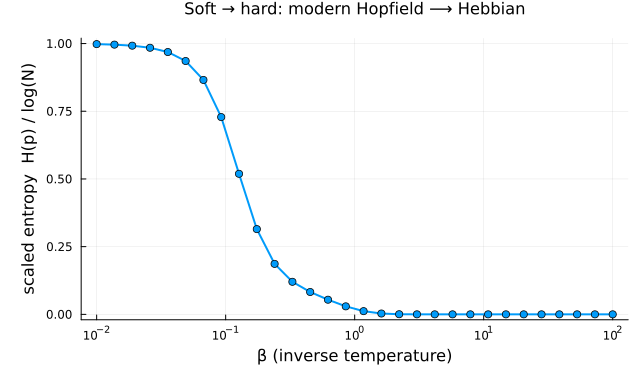

In [12]:
plot(β_grid, recall_scaled_H;
    xscale = :log10, marker = :circle, ms = 4, lw = 2, legend = false,
    ylim = (-0.02, 1.02),
    xlabel = "β (inverse temperature)",
    ylabel = "scaled entropy  H(p) / log(N)",
    title  = "Soft → hard: modern Hopfield ⟶ Hebbian",
    titlefontsize = 11,
    size = (640, 380),
    left_margin = 6Plots.PlotMeasures.mm,
    bottom_margin = 5Plots.PlotMeasures.mm,
    top_margin = 4Plots.PlotMeasures.mm)

### Discussion
1. The β sweep above plots scaled entropy $\tilde{H}(\beta) = H(\mathbf{p}_{\beta})/\log N$ as a continuous, monotone-decreasing function of $\beta$. Connect this curve to the three-step proof you just numerically verified. Specifically:
   * Which numerical claim (1, 2, or 3) does the $\tilde{H} \to 0$ right-edge of the curve correspond to, and why?
   * Claim 2 holds at *every* $\beta > 0$, not just in the limit. Where does that show up in the curve? (Hint: the curve is continuous; it doesn't suddenly jump at any finite $\beta$.)
   * Briefly: why isn't the *left* edge ($\tilde{H} \to 1$, uniform softmax) an H-Mem read? What does $\mathbf{X}\cdot\mathrm{softmax}(\cdot)$ compute when $\mathbf{p}_{\beta}$ is uniform?

Record your answer below and set `did_I_answer_DQ1::Bool` to `true`.


In [13]:
# -- Put your DQ1 answer here as a comment, or in a sibling markdown cell -- #
did_I_answer_DQ1 = false; # TODO: update the flag value {true | false}

___

## Task 2: Stochastic Attention Sampling on MNIST

**The question this task answers.** *Can adding a single Gaussian-noise term to the modern-Hopfield update — no training, no GPU, no learned weights — turn it into a generative model that produces new MNIST digits that we never stored?*

Why this is an interesting question. In Task 1 you proved that the modern-Hopfield update is a content-addressable *recall* operation: it always returns one of the stored columns of $\mathbf{X}$ (in the high-$\beta$ limit, exactly one; at moderate $\beta$, a softmax mixture sharply concentrated on one). A recall loop, by construction, **cannot generate anything new**. The 300 stored MNIST images are all you can ever get out. So a recall network is not a generative model.

Stochastic Attention (SA) of [Varner (2026, arXiv:2603.14717)](https://arxiv.org/abs/2603.14717) makes a one-line change to the update — it adds Gaussian noise — and *claims* that this turns the same machinery into a sampler for an MNIST-shaped distribution:

$$\underbrace{\mathbf{s}_{t+1} \;=\; (1-\eta)\,\mathbf{s}_{t} + \eta\cdot\mathbf{X}\cdot\mathrm{softmax}(\beta\cdot\mathbf{X}^{\top}\mathbf{s}_{t})}_{\text{modern-Hopfield update from Task 1 (η-blended)}} \;+\; \underbrace{\sigma\cdot\boldsymbol{\xi}_{t}}_{\text{the new term}},\qquad \boldsymbol{\xi}_{t}\sim\mathcal{N}(0, \mathbf{I}).$$

The reinterpretation is that the modern-Hopfield log-sum-exp energy $E_{\beta}(\mathbf{s}) = -\tfrac{1}{\beta}\log\!\sum_{j} \exp\!\big(\beta\cdot\mathbf{X}_{:,j}^{\top}\mathbf{s}\big)$ defines a Boltzmann distribution $p_{\beta}(\mathbf{s}) \propto e^{-E_{\beta}(\mathbf{s})}$, the modern-Hopfield update is its score $\nabla_{\mathbf{s}}\log p_{\beta}(\mathbf{s})$, and the noise term turns gradient descent on $E_{\beta}$ into Langevin dynamics that samples from $p_{\beta}$. The pure Langevin SDE corresponds to $\sigma = \sqrt{2\eta/\beta}$, but we expose $\eta$ and $\sigma$ as independent knobs so you can probe the fidelity / novelty trade-off.

**Concretely, Task 2 answers the question with two passes:**

1. **Do the samples *look* like digits?** (Inspection.) Run 20 independent Langevin chains, each warm-started at a random stored image plus a kick, for $n_{\mathrm{steps}} = 5000$ steps. Plot the final 20 states as a grid. **What you should see:** 20 recognizable handwritten 0–9 digits, with visible *novelty* — "in-between" forms (a 9 that drifts toward a 7, an 8 that's half a 3) — because the chain can settle into a convex blend of stored memories.
2. **Are they actually new, or just stored images in disguise?** (Quantitative novelty check, further down.) For each generated sample, compute its Euclidean distance to the *nearest* stored MNIST image; compare the median of those distances to the typical pairwise distance between stored MNIST images. **If `nearest-stored ≈ pairwise`, the samples sit at "normal MNIST inter-image distance" away from the training set — they are genuinely new digits.** If `nearest-stored ≈ 0`, the chain is regurgitating; the noise term is too small to escape the basin of its starting memory.

The chain inspector in between ("start vs. final after 5000 steps") is a sanity check that the noise term is *doing real work* — a chain that just sits on its starting image would mean $\sigma$ is too small or $\beta$ is too large.

**Inputs / outputs of the simulation:**
* In: `sa_model` (built once in Setup with the values you set there — $\beta = 8$, $\eta = 1$, $\sigma = 0.10$); `n_samples_unmasked::Int`; warm-start matrix `unmasked_initial::Matrix{Float64}` of shape $784 \times n$ from `sa_initial_states`; number of Langevin steps `n_steps`.
* Out: `unmasked_samples::Matrix{Float64}` of shape $784 \times n$ — one *generated* digit per column. To experiment with different $\eta$ or $\sigma$, change them in the Setup section and re-run from there.

__Generate samples__. The cell below runs Task 2's first simulation — it builds the warm-start matrix, runs 5000 Langevin steps per chain, and stores the results in `unmasked_samples`.


In [14]:
n_samples_unmasked, unmasked_initial, unmasked_samples = let

    # initialize -
    n_samples_unmasked = 20;

    # build the warm-start matrix EXPLICITLY so we can show start vs final per chain.
    # Each column is a random stored MNIST image plus a small Gaussian kick.
    unmasked_initial = sa_initial_states(sa_model, n_samples_unmasked);

    # run n_steps Langevin steps starting from unmasked_initial.
    unmasked_samples = stochastic_attention_sample(sa_model, n_samples_unmasked;
        n_steps = 5000, sₒ = unmasked_initial);

    # return -
    n_samples_unmasked, unmasked_initial, unmasked_samples;
end

(20, [0.06491579607587511 -0.026572028426926842 … -0.053212323236523355 0.02251973230333007; -0.0009939981218376355 0.005072760575378391 … -0.1418225817716354 -0.06917487787579439; … ; 0.04469118011239752 0.0003759131724909667 … 0.03953092507945628 -0.01901611064454875; 0.03139550063915017 -0.0027237522116066257 … -0.05834851912224246 -0.06973674061106282], [0.023529411764705882 1.8806179250967086e-65 … 9.210694550515788e-70 7.967255435542978e-101; 0.00392156862745098 3.1343632084945145e-66 … 1.535115758419298e-70 0.0196078431372549; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])

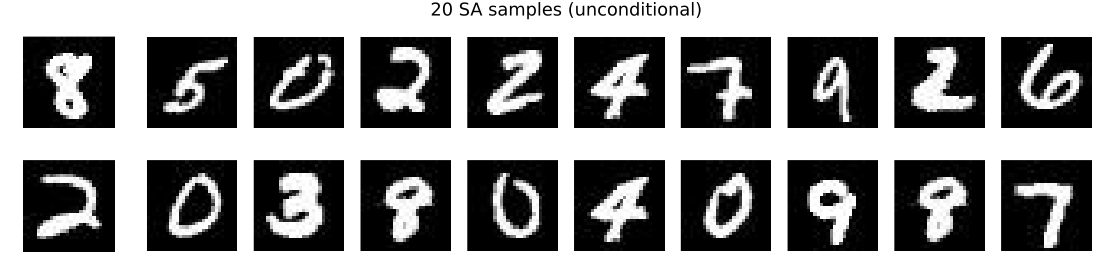

In [15]:
image_grid(unmasked_samples, 10; title = "$(n_samples_unmasked) SA samples (unconditional)")

__Chain inspector__: pick a chain index in `1:n_samples_unmasked` and we show its **starting state** (a random stored MNIST image plus a small Gaussian kick — the warm-start of that Langevin chain) next to **where the chain ended up** after `n_steps = 200` updates. Use this to confirm the chain actually *moved*: a healthy SA chain settles between memories rather than snapping straight back to its starting image. Try a few different `chain_index` values to get a sense of the typical motion.


unconditional · chain 1


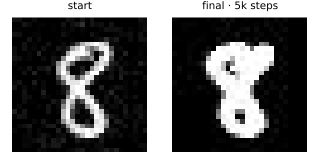

In [16]:
chain_index = let
    chain_index = 1; # TODO: pick a chain index in 1:n_samples_unmasked
    @assert 1 <= chain_index <= n_samples_unmasked
    chain_index;
end
println("unconditional · chain $chain_index")

let
    grid = hcat(unmasked_initial[:, chain_index], unmasked_samples[:, chain_index])
    image_grid(grid, 2; tile_px = 160,
        tile_titles = ["start", "final · 5k steps"])
end

__Novelty check__. The cell below quantifies the visual claim above. It computes two numbers:

* **median nearest-stored distance for SA samples**: for each of the 20 generated samples, find its closest stored pattern in Euclidean distance, then take the median across samples. This is how *far* a typical generated sample sits from the training set.
* **median pairwise distance among stored patterns**: the median Euclidean distance between pairs of stored MNIST images. This is the natural "unit of novelty" — the typical separation between two digits in the training set itself.

**How to read the numbers:**
* If `nearest-stored ≪ pairwise`, the sampler is producing copies (or near-copies) of stored images — **regurgitation mode**, raise $\sigma$ or lower $\beta$.
* If `nearest-stored ≈ pairwise`, generated samples sit at typical inter-image distance from stored patterns — they are genuinely novel digits.
* If `nearest-stored ≫ pairwise`, the chains have wandered off the data manifold entirely — too much noise; samples will not look like digits.


In [17]:
let
    nearest_dist = Float64[]
    for k in 1:size(unmasked_samples, 2)
        s = unmasked_samples[:, k]
        push!(nearest_dist, minimum(norm(s .- X[:, j]) for j in 1:size(X, 2)))
    end
    pairwise_sample = [norm(X[:, i] .- X[:, j]) for i in 1:50 for j in (i + 1):50]
    println("median nearest-stored distance for SA samples: $(round(median(nearest_dist), digits=3))")
    println("median pairwise distance among stored patterns: $(round(median(pairwise_sample), digits=3))")
end

median nearest-stored distance for SA samples: 0.0
median pairwise distance among stored patterns: 10.298


### Discussion
2. Run Task 2 a few times with different combinations of $\beta$, `step_size`, and `noise_scale`. In particular: what happens to the generated samples as $\beta$ grows large (say `64`)? What happens as `noise_scale` grows large (say `0.5`)? Sketch the trade-off; there should be a sweet spot where samples *look* like digits but are not copies of the training set. Explain why this trade-off exists in terms of the SA energy landscape (think about the depth and width of the energy basins around stored patterns at different $\beta$).

Record your answer below and set `did_I_answer_DQ2::Bool` to `true`.


In [18]:
# -- Put your DQ2 answer here as a comment, or in a sibling markdown cell -- #
did_I_answer_DQ2 = false; # TODO: update the flag value {true | false}

___

## Task 3: Class-conditional generation by masking the softmax

**The claim we're testing.** In Task 2 the SA sampler treated every stored memory equally — chains could settle into any of the 300 stored MNIST images and the resulting samples were a mix of all ten digits. We now want to *steer* generation: "give me a 7". The key idea is that the Boltzmann distribution over states is fully determined by the softmax over stored memories, so to **condition** the sampler on a class we only need to change the **softmax logits** — the body of the chain stays identical.

We test two ways of doing this and compare them:

1. **Hard mask** (this section, expected to work cleanly). Set the logit of every off-class memory to $-\infty$:
   $$\mathrm{logit}_{j} \;=\; \beta\cdot\mathbf{X}_{:,j}^{\top}\mathbf{s} \;+\; \begin{cases} 0 & \text{if }y_{j} = \text{target} \\ -\infty & \text{otherwise}\end{cases}$$
   The exponential then sends every off-class entry to exactly $0$, so the softmax distribution lives entirely on the in-class memories. The chain *cannot* visit an off-class attractor — same trick GPT uses for causal masking, applied to a Hopfield memory.
2. **Soft bias** (next section, the calibration-gap demo). Add a finite scalar bonus $b$ to in-class logits and leave off-class logits alone. With a huge $b$ the soft version approaches the hard mask; at $b = 0$ it reduces to the unconditional sampler. The interesting question is what happens *in between*. [Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115) shows that even at very large $b$ the soft version can fail to reach the hard-mask hit rate — the **calibration gap**.

**Inputs and outputs (this section).** What you give the masked sampler:
* `sa_model` — the same SA model from Tasks 1 and 2 (same $\mathbf{X}$, $y$, $\beta$, $\eta$, $\sigma$). **No retraining; no rebuilding.** The mask is a single `Vector{Bool}` of length $N$ passed at sample time.
* `target_class::Int` $\in 0..9$ — which digit you want.
* `class_mask::Vector{Bool}` of length $N = 300$ — `class_mask[j] = (y[j] == target_class)`. This is the boolean **keep-mask**: `true` means "this memory is allowed", `false` means "this memory is forbidden".
* `n_samples_class::Int` — how many chains to run for this class.
* (under the hood) Each chain is initialized as `(X[:,j_random] + small noise)` for a *random in-class* `j`, then run for $n_{\mathrm{steps}} = 5000$ Langevin updates with the masked softmax, then a final noise-free read-out step.

What you get back: `class_samples::Matrix{Float64}` of shape $784 \times n_{\mathrm{samples\_class}}$ — one generated digit per column, each one a convex blend of stored target-class memories (because the mask blocks every off-class attractor).

**How we'll show it (three simulations in this section):**
1. **Generate one batch of target-class samples** and look at them as a grid. Pick `target_class`, build `class_mask`, run the sampler, plot the 20 generated digits. **What you should see:** all 20 should look like the requested digit (with stylistic variation — different stored 7s blended together).
2. **Chain inspector** (next markdown cell). For a chosen chain, show its starting image (a random in-class stored 7, plus a kick) next to its final state after 5000 Langevin steps, so you can see the *trajectory* of one chain. **What you should see:** the start is a recognizable in-class digit; the final is a different in-class digit (the chain has mixed across in-class memories) — but both are 7s.
3. **Hit-rate table** (Fidelity check section). To turn "looks like a 7" into a number, classify each sample by its nearest per-class centroid and report the fraction that maps back to `target_class`. **What you should see:** hit rates well above $0.7$ for every class — the hard mask works.


In [19]:
target_class, n_samples_class, class_mask = let

    # initialize -
    target_class = 3;          # TODO: which digit to generate (0..9)
    n_samples_class = 20;      # TODO: how many samples per class
    class_mask = [yj == target_class for yj in y];
    println("class_mask leaves ", count(class_mask), " of ", length(class_mask), " stored patterns visible")

    # return -
    target_class, n_samples_class, class_mask;
end

class_mask leaves 30 of 300 stored patterns visible


(3, 20, Bool[0, 0, 0, 0, 0, 0, 0, 0, 0, 0  …  0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [20]:
class_initial, class_samples = let

    # build the warm-start matrix EXPLICITLY (drawn only from in-class memories
    # because we pass hard_mask = class_mask) so we can show start vs final per chain.
    class_initial = sa_initial_states(sa_model, n_samples_class; hard_mask = class_mask);

    # generate the class-conditional samples via the hard mask, starting from class_initial -
    class_samples = stochastic_attention_sample(sa_model, n_samples_class;
        n_steps = 5000, hard_mask = class_mask, sₒ = class_initial);

    # return -
    class_initial, class_samples;
end

([-0.01610782404121193 -0.059968215804027836 … 0.03796467687835999 -0.04543867204728708; 0.03794764032297756 0.036296282025165376 … 0.05255041866582838 -0.08177050727712867; … ; 0.022537664483274152 -0.054115820566481926 … 0.011959878370720411 -0.05296417371540181; 0.14422761448928928 0.07678280090049247 … 0.014457531173942134 0.01643720732359146], [1.9613665901840184e-280 8.179660736149816e-279 … 6.3253671103699935e-276 1.5068769515970564e-283; 1.4804832072711367e-261 2.77424719676713e-262 … 8.405426368559324e-261 5.258170451653524e-264; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])

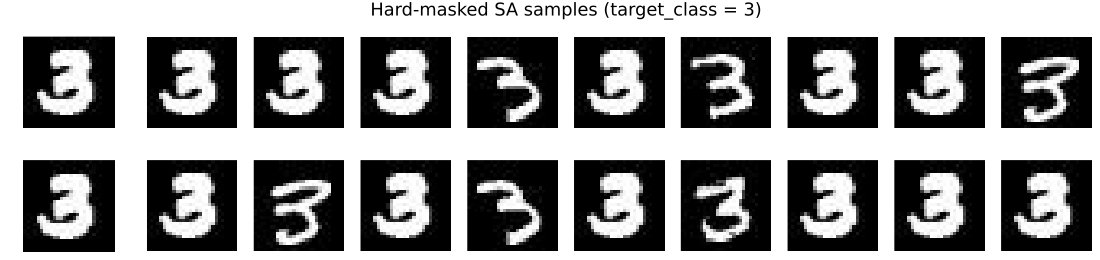

In [21]:
image_grid(class_samples, 10;
    title = "Hard-masked SA samples (target_class = $(target_class))")

__Chain inspector (masked)__: pick a chain index in `1:n_samples_class` and we show its **starting state** (a random in-class stored MNIST image plus a small Gaussian kick) next to **where the chain ended up** after 5000 masked Langevin steps. Because every off-class memory has logit $-\infty$, the chain is *trapped* on the in-class subset of the energy landscape — both tiles should be the requested digit, but the final tile should differ from the start (showing that the chain mixed across in-class memories rather than just regurgitating its starting image).


class 3 · chain 1


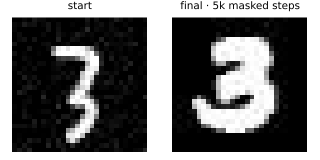

In [22]:
class_chain_index = let
    class_chain_index = 1; # TODO: pick a chain index in 1:n_samples_class
    @assert 1 <= class_chain_index <= n_samples_class
    class_chain_index;
end
println("class $target_class · chain $class_chain_index")

let
    grid = hcat(class_initial[:, class_chain_index], class_samples[:, class_chain_index])
    image_grid(grid, 2; tile_px = 160,
        tile_titles = ["start", "final · 5k masked steps"])
end

### Fidelity check
We want a deterministic, training-free way to ask "did this generated sample look like the target class?" The cheapest classifier is the **nearest-mean classifier**: label a sample by its closest per-class centroid in pixel space. The centroids `class_means::Dict{Int, Vector{Float64}}` were precomputed in the Setup section.

We loop over all ten classes, draw `n_samples_class` samples each under the hard mask, and report the fraction that the nearest-mean classifier maps back to the requested class. A perfect hard mask should give very high fractions across the board.

The code below stores the per-class hit-rate table in `hardmask_table::DataFrame` for use in subsequent cells.


In [23]:
hardmask_table = let
    df = DataFrame(target = Int[], hits = Int[], total = Int[], hit_rate = Float64[])
    for c in 0:9
        m = [yj == c for yj in y]
        samples = stochastic_attention_sample(sa_model, n_samples_class;
            n_steps = 5000, hard_mask = m)
        labels = [classify_by_nearest_mean(samples[:, k], class_means) for k in 1:n_samples_class]
        h = count(==(c), labels)
        push!(df, (target = c, hits = h, total = n_samples_class, hit_rate = h / n_samples_class))
    end
    pretty_table(df)
    df
end;

┌────────┬───────┬───────┬──────────┐
│ target │  hits │ total │ hit_rate │
│  Int64 │ Int64 │ Int64 │  Float64 │
├────────┼───────┼───────┼──────────┤
│      0 │    20 │    20 │      1.0 │
│      1 │    20 │    20 │      1.0 │
│      2 │    17 │    20 │     0.85 │
│      3 │    16 │    20 │      0.8 │
│      4 │    15 │    20 │     0.75 │
│      5 │    14 │    20 │      0.7 │
│      6 │    19 │    20 │     0.95 │
│      7 │    17 │    20 │     0.85 │
│      8 │    19 │    20 │     0.95 │
│      9 │    19 │    20 │     0.95 │
└────────┴───────┴───────┴──────────┘


### Hard mask vs. soft bias: the calibration gap
A hard mask zeros out off-class logits exactly. A soft bias instead adds a finite scalar bonus to in-class logits and leaves off-class logits in play. With a large bias the soft version approaches the hard version; at zero bias it reduces to the unconditional sampler. In between, the soft version interpolates between the two **in attention space**; but, as [Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115) shows, that interpolation does not always land where you would naively expect in pixel space. The discrepancy is the **calibration gap**.

We sweep the bias and see what happens.

The code below stores the bias-versus-hit-rate table in `softbias_table::DataFrame` for use in subsequent cells.


In [24]:
softbias_table = let
    df = DataFrame(bias = Float64[], target = Int[], hits = Int[], total = Int[], hit_rate = Float64[])
    in_class = [yj == target_class for yj in y]
    for b in [0.0, 1.0, 5.0, 20.0, 100.0]
        sb_vec = Float64.([m ? b : 0.0 for m in in_class])
        samples = stochastic_attention_sample(sa_model, n_samples_class;
            n_steps = 5000, soft_bias = sb_vec)
        labels = [classify_by_nearest_mean(samples[:, k], class_means) for k in 1:n_samples_class]
        h = count(==(target_class), labels)
        push!(df, (bias = b, target = target_class, hits = h, total = n_samples_class, hit_rate = h / n_samples_class))
    end
    pretty_table(df)
    df
end;

┌─────────┬────────┬───────┬───────┬──────────┐
│    bias │ target │  hits │ total │ hit_rate │
│ Float64 │  Int64 │ Int64 │ Int64 │  Float64 │
├─────────┼────────┼───────┼───────┼──────────┤
│     0.0 │      3 │     4 │    20 │      0.2 │
│     1.0 │      3 │     3 │    20 │     0.15 │
│     5.0 │      3 │     3 │    20 │     0.15 │
│    20.0 │      3 │     4 │    20 │      0.2 │
│   100.0 │      3 │    12 │    20 │      0.6 │
└─────────┴────────┴───────┴───────┴──────────┘


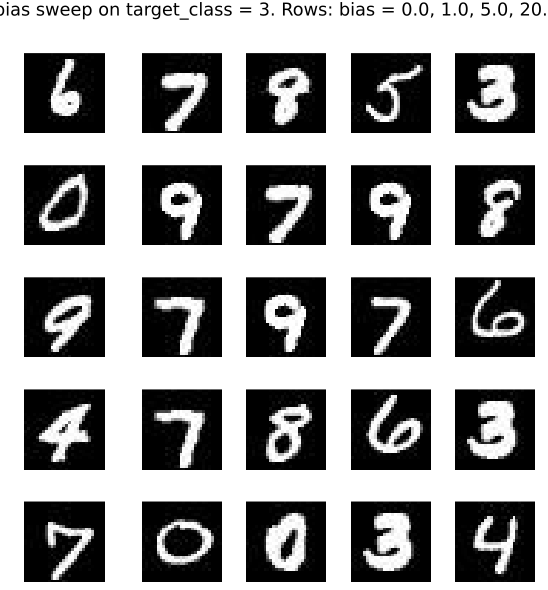

In [25]:
# Visualize one batch from each bias setting side-by-side at a fixed target class.
let
    biases = [0.0, 1.0, 5.0, 20.0, 100.0]
    n_per = 5
    grid_cols = Vector{Vector{Float64}}()
    in_class = [yj == target_class for yj in y]
    for b in biases
        sb_vec = Float64.([m ? b : 0.0 for m in in_class])
        s = stochastic_attention_sample(sa_model, n_per; n_steps = 5000, soft_bias = sb_vec)
        for k in 1:n_per
            push!(grid_cols, s[:, k])
        end
    end
    G = reduce(hcat, grid_cols)
    image_grid(G, n_per; title = "Soft-bias sweep on target_class = $(target_class). Rows: bias = " * join(string.(biases), ", "))
end

### Discussion
3. Compare the hard-mask hit-rate table with the soft-bias hit-rate table.
   * For a bias just above zero, the hit rate barely moves; for very large bias, it climbs toward the hard-mask value. Why is this? Think about the magnitude of the inner-product term $\beta\cdot\mathbf{X}^{\top}\mathbf{s}$ versus the additive bias.
   * Even at bias = 100, the soft-bias version may not reach 100% hit rate, while the hard mask does. What is being lost? Connect this to the **calibration gap** of [Varner (2026, arXiv:2603.20115)](https://arxiv.org/abs/2603.20115): the conditioning is exact at the level of the sampler's softmax weights, but the *decoded* sample can disagree because the inner-product term steers the chain toward whichever attractor is closest to the current state, regardless of class.

Record your answer below and set `did_I_answer_DQ3::Bool` to `true`.


In [26]:
# -- Put your DQ3 answer here as a comment, or in a sibling markdown cell -- #
did_I_answer_DQ3 = false; # TODO: update the flag value {true | false}

## Fun (totally optional) directions we could go with this idea
This was a proof-of-concept exploration of masked Stochastic Attention on MNIST. Real applications are well beyond image-based digits, and the three papers below (all of which were born from this class) sketch where the idea goes next.

### Maybe a different application?
* __Small protein families__. A small alignment of <100 sequences from a single Pfam family is exactly the regime where deep generative models overfit, but where Stochastic Attention has linear-in-alignment-size cost on a laptop. See [Varner, *Training-Free Generation of Protein Sequences from Small Family Alignments via Stochastic Attention*, arXiv:2603.14717](https://arxiv.org/abs/2603.14717).
* __Conditioning on a binding screen__. If you have a small functional subset of a family (say, hits from a binding screen) and want to bias generation toward proteins that share that property, the multiplicity-weighted soft bias of this practicum's Task 3 is exactly the recipe; see [Varner, *Conditioning Protein Generation via Hopfield Pattern Multiplicity*, arXiv:2603.20115](https://arxiv.org/abs/2603.20115). The same paper diagnoses the calibration-gap phenomenon you saw in DQ3.
* __Synthetic patient cohorts__. Replacing "stored protein sequence" with "stored longitudinal patient record" lets SA augment small clinical cohorts of <30 patients in domains like pregnancy and rare disease without retraining. See [Varner, Bravo, McBride, Orfeo, Bernstein, *Validated Synthetic Patient Generation for Small Longitudinal Cohorts*, arXiv:2604.07557](https://arxiv.org/abs/2604.07557).

### Other things to try
* __Causal mask__: instead of masking by class, set up a causal mask (`mask[j] = (j ≤ t)` at time step `t`) so the chain only attends to "earlier" memories, a Hopfield analogue of GPT's autoregressive generation.
* __Different inverse temperatures inside vs. outside the mask__: replace the scalar $\beta$ with a vector of per-pattern temperatures. This decouples *how confident* the sampler is about each memory from *which* memories are visible.
* __Compare to the spiking H-Mem of L15b__. The hard-mask SA produces a class-conditional generator from a static memory; the spiking H-Mem produces one-shot recall from a dynamically-written memory. Sketch how you would turn one into the other.

___

## Summary
This practicum connected the Spiking Hebbian Memory Network of L15 to the modern Hopfield network of Ramsauer et al. (2020) and to the Stochastic Attention sampler of Varner (2026), then introduced a single boolean mask on the attention softmax as a route to class-conditional generation on MNIST. The same memory mechanism therefore powers retrieval, generation, and conditional generation, and the choice of mask versus bias is a practical, training-free knob with measurable trade-offs.

## Key Takeaways
* **The Hebbian read step is the cold limit of softmax attention:** When the inverse temperature grows large, the softmax over stored patterns collapses to a one-hot indicator of the nearest memory. The modern-Hopfield retrieval rule and the H-Mem matrix-vector recall therefore describe the same operation at different temperatures.
* **Stochastic Attention generates novel samples without training:** Injecting Gaussian noise into the modern-Hopfield update produces a Langevin-style sampler whose stationary distribution is the Hopfield Boltzmann measure over stored memories. Cost is linear in the number of stored patterns, and the sampler runs on a laptop with no gradient descent and no tuned weights.
* **Hard masks condition cleanly while soft biases do not:** A boolean mask over the attention softmax delivers near-perfect class-conditional generation by exactly excluding off-class memories. A finite scalar bias on in-class logits steers attention but rarely overcomes the inner-product term that dominates the softmax, leaving a calibration gap between attention-space conditioning and pixel-space output.

A single concluding sentence goes here
___

## Tests
In the code block below, we check some values in your notebook and give you feedback on which items are correct or different. Unhide the code block (if you are curious) to see how the tests are set up.

class 3 · chain 1


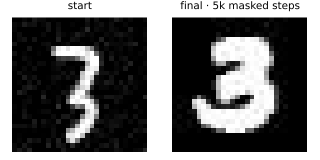

In [27]:
class_chain_index = let
    class_chain_index = 1; # TODO: pick a chain index in 1:n_samples_class
    @assert 1 <= class_chain_index <= n_samples_class
    class_chain_index;
end
println("class $target_class · chain $class_chain_index")

let
    grid = hcat(class_initial[:, class_chain_index], class_samples[:, class_chain_index])
    image_grid(grid, 2; tile_px = 160,
        tile_titles = ["start", "final · 5k masked steps"])
end